# <font style="color:rgb(0,91,150)">Color Theory</font>


### <span style="color:green;">Loading Images with OpenCV</span>

Let's begin by reading an image from disk using OpenCV's `imread` function. The syntax for Python and C++ is as follows:

These commands load the specified image from disk into memory. In Python, the image is stored as a NumPy multidimensional array object, while in C++ it's stored as a `Mat` object.

```python
# Python
img = cv2.imread("image.png", cv2.IMREAD_COLOR)
```

```c++
// C++
Mat img = imread("image.png", IMREAD_COLOR);
```

Here, the first argument is the filename of the image you want to read. The second argument is an optional flag that specifies the image reading mode:

- `cv2.IMREAD_COLOR`: Loads a color image (any transparency will be ignored, default mode)
- `cv2.IMREAD_GRAYSCALE`: Loads image in grayscale mode
- `cv2.IMREAD_UNCHANGED`: Loads image including alpha channel

The `imread` function returns a multi-dimensional array containing the image's pixel intensity values. For complete documentation of the `imread` function and its options, see:  
[OpenCV official documentation](https://docs.opencv.org/4.7.0/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56)



In [7]:
# importar bibliotecas
import cv2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from pathlib import Path

matplotlib.rcParams['figure.figsize'] = (6.0, 6.0)
matplotlib.rcParams['image.cmap'] = 'gray'
%matplotlib inline

### Splitting and Merging Channels

It's important to understand what we're about to do. We'll use the `plt.imshow(img)` method. This method is part of the *matplotlib* library and is used to display images.

Key consideration:  
The `plt.imshow()` method expects images in RGB format, but the *OpenCV* library loads images in BGR format. Therefore, if you load your image using *OpenCV*, you'll need to convert the color channels from BGR to RGB before displaying the image. However, in this example, we're displaying the image without performing this conversion.

In [9]:
image_carmen = Path.cwd().parent / "data" / "carmen_01.jpg"
img = cv2.imread(image_carmen)
img.shape

(509, 717, 3)

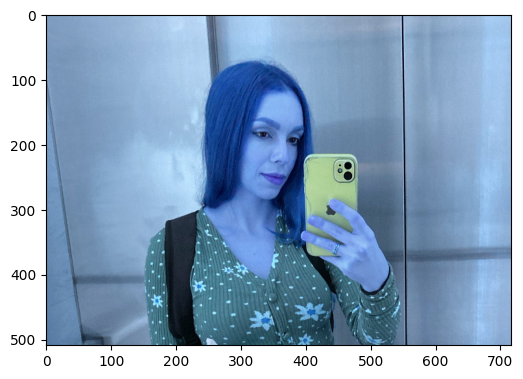

In [10]:
plt.imshow(img)

### Preparing for the Next Code Step

We'll now use `plt.imshow(img[...,::-1])`. Here's what this operation does:

1. **Channel Order Reversal**:
   - Recall that OpenCV loads images in **BGR** format
   - `plt.imshow()` expects **RGB** format
   - The slice operation `[...,::-1]` reverses the channel order

2. **Technical Breakdown**:
   ```python
   img[...,::-1]  # Reverse channels along the last axis (BGR → RGB)

In [11]:
img_correta = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

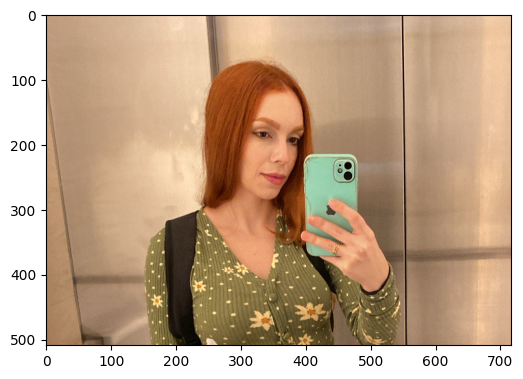

In [12]:
plt.imshow(img[..., ::-1]);

In the next code segment, we're performing several important steps:

First, we're splitting the image into its separate color channels using b, g, r = cv2.split(img). This gives us three grayscale images, each representing the intensity of blue, green, and red respectively for every pixel in the original image.

Next, we create a new figure with a specific size using plt.figure(figsize=[20,5]). This sets up our plotting area to be 20 units wide and 5 units tall.

Then, using plt.subplot(), we create multiple subplots within the same figure. Each subplot will display:

One of the color channel images we created (blue, green, or red)

The original image converted from BGR to RGB format

The [...,::-1] slice operation we apply to the original image converts it from OpenCV's default BGR format to the RGB format that matplotlib expects for proper color display. This is crucial because while OpenCV stores images in BGR order, most other libraries (including matplotlib) work with RGB order.



Text(0.5, 1.0, 'Imagem RGB')

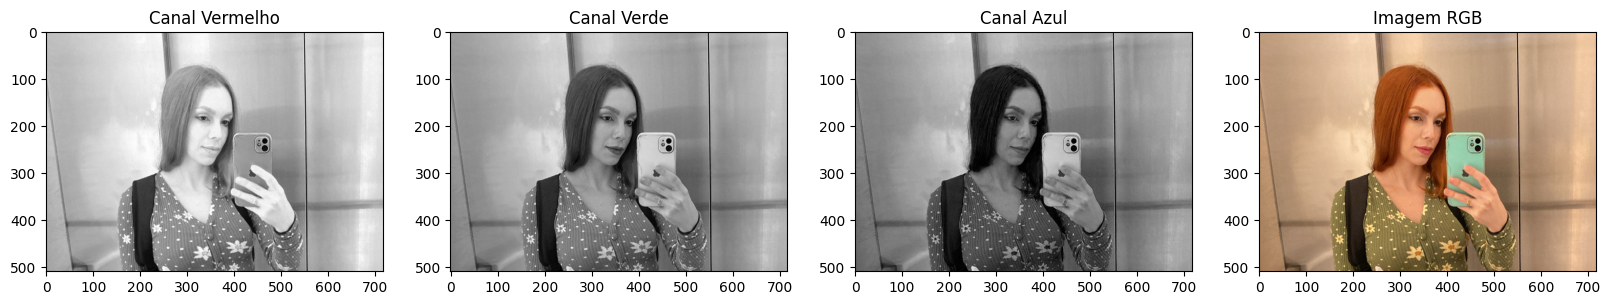

In [13]:
# Dividindo a imagem em seus respectivos canais de cor.
b, g, r = cv2.split(img)

# Criando uma nova figura com tamanho específico.
plt.figure(figsize=[20,5])

plt.subplot(141);
plt.imshow(r);
plt.title('Canal Vermelho')

plt.subplot(142);
plt.imshow(g);
plt.title('Canal Verde')

plt.subplot(143);
plt.imshow(b);
plt.title('Canal Azul')

# realizando o merge dos canais
img_merged = cv2.merge((b, g, r))

# plots com canais separados e imagem final composta
plt.subplot(144);
plt.imshow(img_merged[...,::-1]);
plt.title('Imagem RGB')

In the previous example, we loaded an image without transparency. As you observed when running img.shape, there were only 3 channels. Now, we'll work with a different image type - a PNG containing an alpha transparency channel. When loading this image with cv2.imread() using -1 as the second argument to ensure all channels (including alpha) are loaded, we notice img.shape returns 4 channels.

This occurs because PNG images can include a fourth channel - the alpha channel. This channel adds transparency information, allowing certain pixels to be partially or fully transparent. To create such an image, I used an online photo editor to remove the background and make it transparent.

When working with these images, it's essential to account for this fourth channel. Here's the complete process:

1. Channel separation:

    ``` bash
    carmen_bgr = carmen_alpha[:,:,0:3]  # Extract BGR channels
    carmen_alpha = carmen_alpha[:,:,3]   # Extract alpha channel
    ```
The alpha channel controls each pixel's transparency level.

2. Create base image:

    ``` bash
    blank_image = np.zeros(carmen_bgr.shape, dtype=np.uint8)
    Generates a black image matching the original's dimensions as our canvas.
    ```

3. Apply alpha mask:

    ``` bash
    carmen_bgr_masked = cv2.bitwise_and(carmen_bgr, carmen_bgr, mask=carmen_alpha)
    The bitwise AND operation applies transparency by only keeping pixels where the alpha mask is non-zero.
    ```

4. Visualization:

    ``` bash
    plt.imshow(carmen_bgr_masked[:,:,::-1])  # BGR→RGB conversion
    plt.imshow(carmen_alpha, cmap='gray')    # Show alpha channel
    The slice [::-1] converts from OpenCV's BGR to matplotlib's expected RGB format.
    ```

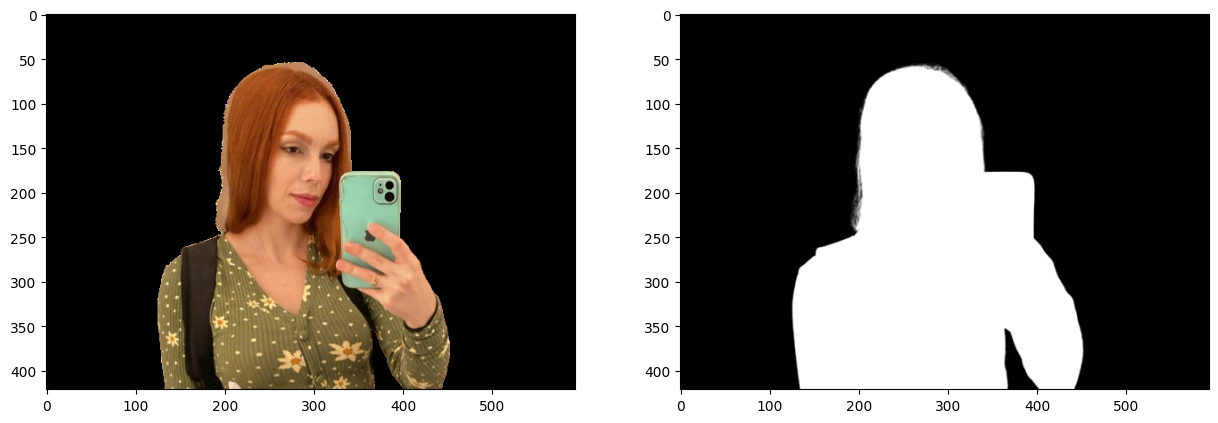

In [ ]:
import numpy as np

image_carmen = Path.cwd().parent / "data" / "carmen_removebg.png"
carmen_alpha = cv2.imread(image_carmen, -1)

carmen_bgr = carmen_alpha[:,:,0:3]
carmen_alpha = carmen_alpha[:,:,3]

blank_image = np.zeros(carmen_bgr.shape, dtype=np.uint8)

carmen_bgr_masked = cv2.bitwise_and(carmen_bgr, carmen_bgr, mask=carmen_alpha)

plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(carmen_bgr_masked[:,:,::-1]);
plt.subplot(122);plt.imshow(carmen_alpha, cmap='gray');